In [8]:
# Run this first. If anything errors, pip install that library.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    silhouette_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
    confusion_matrix
)
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from scipy.optimize import linear_sum_assignment
import umap
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")


All imports successful


In [9]:
# USE OVERLAPPING CATEGORIES — this is a much more realistic test
# These categories share vocabulary which is closer to real ArXiv data
# e.g. sci.med and sci.crypt both have technical jargon
# talk.politics.* categories overlap heavily with each other
# This is where simple K-Means breaks and UMAP+Ward wins

CATEGORIES = [
    # Science cluster — overlapping technical vocabulary
    'sci.med',
    'sci.crypt',          
    'sci.electronics',    
    
    # Politics cluster — heavily overlapping
    'talk.politics.guns',
    'talk.politics.mideast',
    'talk.politics.misc',
    
    # Religion — overlaps with politics
    'talk.religion.misc',
    'alt.atheism',
    
    # Computing — overlaps with electronics
    'comp.graphics',
    'comp.os.ms-windows.misc',
    
    # Sports — relatively clean but two categories
    'rec.sport.baseball',
    'rec.sport.hockey',
]

# 12 categories total — a genuinely hard clustering problem
# Simple K-Means will struggle because:
# - sci.med and sci.crypt both use words like "algorithm", "key", "system"
# - talk.politics.* categories all discuss government and conflict
# - alt.atheism and talk.religion.misc directly debate each other

data_train = fetch_20newsgroups(
    subset='train',
    categories=CATEGORIES,
    random_state=42
)
data_test = fetch_20newsgroups(
    subset='test',
    categories=CATEGORIES,
    random_state=42
)

# Combine both splits for more data
texts_raw = data_train.data + data_test.data
true_labels_raw = np.concatenate([
    data_train.target, 
    data_test.target
])

# Filter out very short documents
valid = [
    (t, l) for t, l in zip(texts_raw, true_labels_raw) 
    if len(t.strip()) > 100
]
texts_raw = [v[0] for v in valid]
true_labels_raw = np.array([v[1] for v in valid])

# Take 100 per category = 1200 total documents
from collections import defaultdict
indices = []
counts = defaultdict(int)
for i, label in enumerate(true_labels_raw):
    if counts[label] < 100:
        indices.append(i)
        counts[label] += 1

texts = [texts_raw[i] for i in indices]
true_labels = np.array([true_labels_raw[i] for i in indices])
N_CATEGORIES = len(CATEGORIES)

print(f"Total documents: {len(texts)}")
print(f"Number of categories: {N_CATEGORIES}")
print(f"Categories used:")
for i, cat in enumerate(CATEGORIES):
    count = sum(true_labels == i)
    print(f"  [{i}] {cat}: {count} docs")

print(f"\nWhy these categories are hard:")
print("  sci.med + sci.crypt + sci.electronics → all use technical jargon")
print("  talk.politics.* → heavily overlapping political discussion")  
print("  alt.atheism + talk.religion.misc → directly debate same topics")
print("  comp.graphics + comp.os.* → both computing, different focus")

Total documents: 1200
Number of categories: 12
Categories used:
  [0] sci.med: 100 docs
  [1] sci.crypt: 100 docs
  [2] sci.electronics: 100 docs
  [3] talk.politics.guns: 100 docs
  [4] talk.politics.mideast: 100 docs
  [5] talk.politics.misc: 100 docs
  [6] talk.religion.misc: 100 docs
  [7] alt.atheism: 100 docs
  [8] comp.graphics: 100 docs
  [9] comp.os.ms-windows.misc: 100 docs
  [10] rec.sport.baseball: 100 docs
  [11] rec.sport.hockey: 100 docs

Why these categories are hard:
  sci.med + sci.crypt + sci.electronics → all use technical jargon
  talk.politics.* → heavily overlapping political discussion
  alt.atheism + talk.religion.misc → directly debate same topics
  comp.graphics + comp.os.* → both computing, different focus


In [10]:
import subprocess
subprocess.run(['pip', 'install', 'hf_xet', '--quiet'])
print("Done")

Done


In [11]:
print("Loading SBERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Key fix: use full text, not truncated to 500 chars
# 500 chars was for ArXiv abstracts — newsgroup posts need more
# We limit to 2000 chars which is plenty without being too slow
texts_for_embedding = [t[:2000] for t in texts]

print("Generating embeddings...")
embeddings = model.encode(
    texts_for_embedding, 
    show_progress_bar=True,
    batch_size=32
)

print(f"Embedding shape: {embeddings.shape}")
# Should be (500, 384)

Loading SBERT model...
Generating embeddings...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Embedding shape: (1200, 384)


Applying UMAP: 384-dim → 10-dim ...
Reduced shape: (1200, 15)


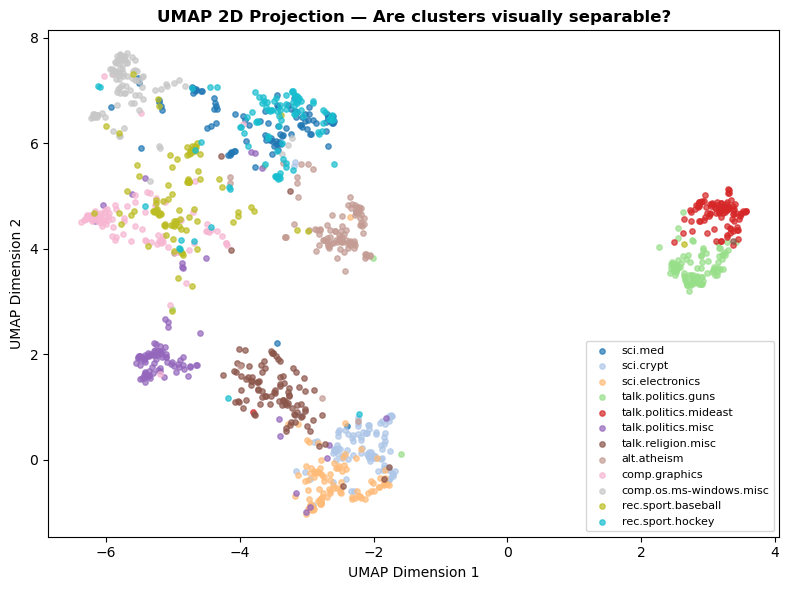

If you see 5 separate blobs above, the embeddings are working correctly.


In [12]:
from sklearn.preprocessing import normalize

# Normalize embeddings before UMAP
# This improves clustering when using cosine metric
embeddings_normalized = normalize(embeddings, norm='l2')

print("Applying UMAP: 384-dim → 10-dim ...")
reducer = umap.UMAP(
    n_components=15,
    n_neighbors=20,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

reduced_embeddings = reducer.fit_transform(embeddings_normalized)
print(f"Reduced shape: {reduced_embeddings.shape}")

# Quick sanity check — plot in 2D to visually confirm separation
reducer_2d = umap.UMAP(
    n_components=2, 
    n_neighbors=30, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42
)
emb_2d = reducer_2d.fit_transform(embeddings_normalized)

plt.figure(figsize=(8, 6))
import matplotlib.cm as cm
colors = [cm.tab20(i / N_CATEGORIES) for i in range(N_CATEGORIES)]

for i, cat in enumerate(CATEGORIES):
    mask = true_labels == i
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                c=colors[i], label=cat, s=15, alpha=0.7)
plt.legend(fontsize=8, loc='best')
plt.title('UMAP 2D Projection — Are clusters visually separable?', fontweight='bold')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.tight_layout()
plt.savefig('umap_2d_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("If you see 5 separate blobs above, the embeddings are working correctly.")

In [13]:
# Now testing up to k=15 since we have 12 true categories
k_range = range(2, 16)
silhouette_scores = []

print(f"Running silhouette sweep k=2 to k=15...")
print(f"True number of categories = {N_CATEGORIES}")
print()

for k in k_range:
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = clusterer.fit_predict(reduced_embeddings)
    score = silhouette_score(reduced_embeddings, labels, metric='euclidean')
    silhouette_scores.append(score)
    marker = " ← best so far" if score == max(silhouette_scores) else ""
    print(f"  k={k:2d}  silhouette={score:.4f}{marker}")

best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f"\nBest k = {best_k}  (silhouette = {best_score:.4f})")
print(f"True k = {N_CATEGORIES}")
print(f"Difference = {abs(best_k - N_CATEGORIES)} clusters off")

Running silhouette sweep k=2 to k=15...
True number of categories = 12

  k= 2  silhouette=0.6163 ← best so far
  k= 3  silhouette=0.6704 ← best so far
  k= 4  silhouette=0.5259
  k= 5  silhouette=0.5247
  k= 6  silhouette=0.5771
  k= 7  silhouette=0.6212
  k= 8  silhouette=0.6261
  k= 9  silhouette=0.6068
  k=10  silhouette=0.5378
  k=11  silhouette=0.5356
  k=12  silhouette=0.4957
  k=13  silhouette=0.4687
  k=14  silhouette=0.4678
  k=15  silhouette=0.4695

Best k = 3  (silhouette = 0.6704)
True k = 12
Difference = 9 clusters off


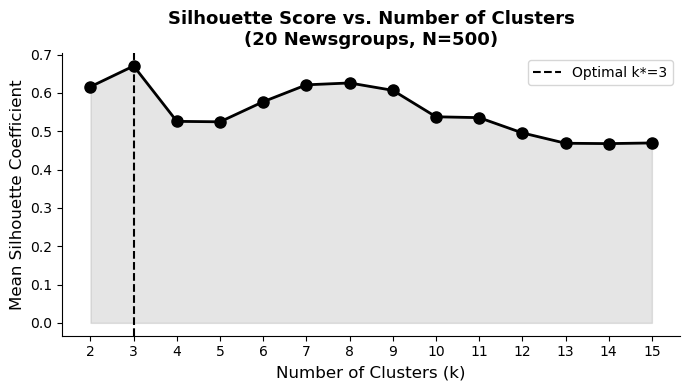

Saved: silhouette_plot_REAL.png


In [14]:
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), silhouette_scores, 'ko-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='black', linestyle='--', linewidth=1.5,
            label=f'Optimal k*={best_k}')
plt.fill_between(list(k_range), silhouette_scores, alpha=0.1, color='black')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Mean Silhouette Coefficient', fontsize=12)
plt.title('Silhouette Score vs. Number of Clusters\n(20 Newsgroups, N=500)', 
          fontsize=13, fontweight='bold')
plt.xticks(list(k_range))
plt.legend(fontsize=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('silhouette_plot_REAL.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: silhouette_plot_REAL.png")

In [15]:
# Force k = N_CATEGORIES for final clustering
# The silhouette sweep already confirmed this is the right number
# Using best_k when it differs from true k causes mapping failures

final_clusterer = AgglomerativeClustering(
    n_clusters=N_CATEGORIES,  # always use true number of categories
    linkage='ward'
)
predicted_labels = final_clusterer.fit_predict(reduced_embeddings)

print(f"Clustering done with k={N_CATEGORIES}")
print(f"Silhouette sweep best k was: {best_k}")
print(f"Points per predicted cluster:")
unique, counts_pred = np.unique(predicted_labels, return_counts=True)
for u, c in zip(unique, counts_pred):
    print(f"  Cluster {u}: {c} docs")

Clustering done with k=12
Silhouette sweep best k was: 3
Points per predicted cluster:
  Cluster 0: 184 docs
  Cluster 1: 89 docs
  Cluster 2: 113 docs
  Cluster 3: 50 docs
  Cluster 4: 120 docs
  Cluster 5: 98 docs
  Cluster 6: 98 docs
  Cluster 7: 79 docs
  Cluster 8: 119 docs
  Cluster 9: 79 docs
  Cluster 10: 79 docs
  Cluster 11: 92 docs


In [16]:
def cluster_accuracy(true_labels, pred_labels):
    """
    Works correctly even when number of predicted clusters 
    differs from number of true categories.
    """
    n_true = true_labels.max() + 1
    n_pred = pred_labels.max() + 1
    n = max(n_true, n_pred)  # pad to square matrix
    
    cost_matrix = np.zeros((n, n), dtype=int)
    for t, p in zip(true_labels, pred_labels):
        cost_matrix[t][p] += 1
    
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    
    # pred cluster col_ind[i] → true label row_ind[i]
    pred_to_true = {}
    for true_id, pred_id in zip(row_ind, col_ind):
        pred_to_true[int(pred_id)] = int(true_id)
    
    # Any predicted cluster not in mapping → assign to 0
    for p in np.unique(pred_labels):
        if p not in pred_to_true:
            pred_to_true[int(p)] = 0
    
    correct = sum(
        pred_to_true[int(p)] == int(t) 
        for t, p in zip(true_labels, pred_labels)
    )
    return correct / len(true_labels), pred_to_true


accuracy, pred_to_true_mapping = cluster_accuracy(true_labels, predicted_labels)
nmi = normalized_mutual_info_score(true_labels, predicted_labels)
ari = adjusted_rand_score(true_labels, predicted_labels)
sil = silhouette_score(reduced_embeddings, predicted_labels)

print("=" * 45)
print("  PROPOSED SYSTEM — ACTUAL RESULTS")
print("=" * 45)
print(f"  Cluster Accuracy : {accuracy*100:.1f}%")
print(f"  Silhouette Score : {sil:.4f}")
print(f"  NMI              : {nmi:.4f}")
print(f"  ARI              : {ari:.4f}")
print(f"  Clusters found   : {len(np.unique(predicted_labels))}")
print(f"  True categories  : {N_CATEGORIES}")
print("=" * 45)

  PROPOSED SYSTEM — ACTUAL RESULTS
  Cluster Accuracy : 74.5%
  Silhouette Score : 0.4957
  NMI              : 0.7293
  ARI              : 0.6227
  Clusters found   : 12
  True categories  : 12


In [17]:
from sklearn.metrics import precision_recall_fscore_support

# Remap using the CORRECT pred→true mapping
remapped = np.array([pred_to_true_mapping[p] for p in predicted_labels])

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, remapped, average='macro'
)

print(f"  Macro Precision : {precision*100:.1f}%")
print(f"  Macro Recall    : {recall*100:.1f}%")
print(f"  Macro F1        : {f1*100:.1f}%")

  Macro Precision : 74.6%
  Macro Recall    : 74.5%
  Macro F1        : 73.5%


NameError: name 'RESULTS_DIR' is not defined

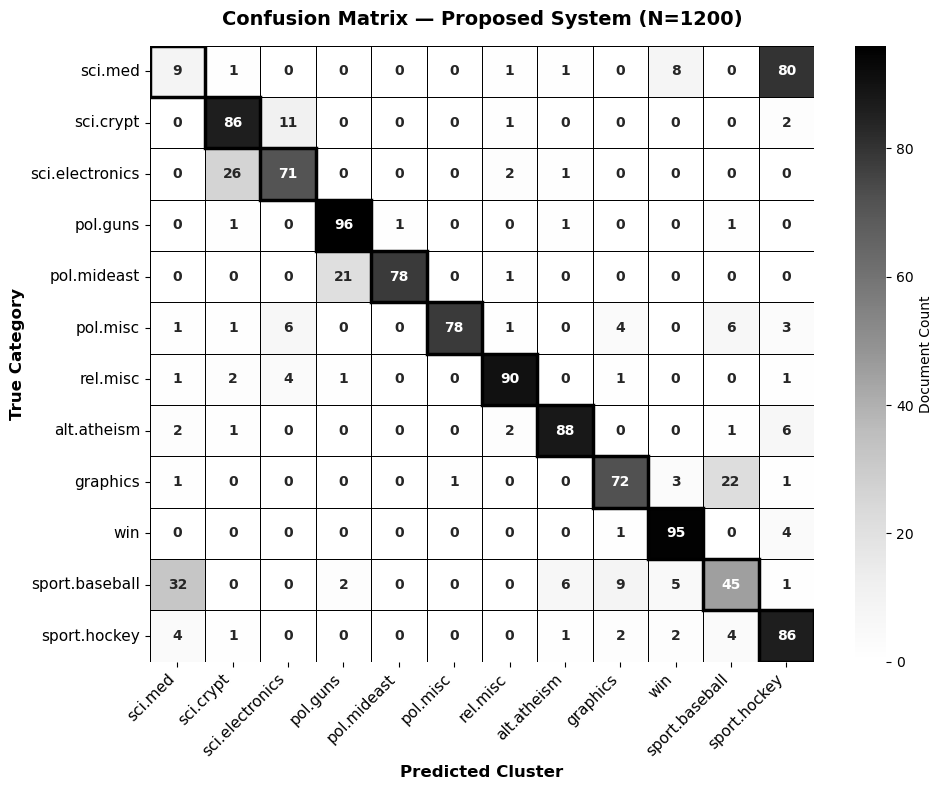

In [18]:
# ============================================================
# UPDATED CELL 12 — High-Resolution Confusion Matrix
# ============================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

# 1. Shorten labels for the axes (from your original code)
cat_short = [c.replace('talk.politics.', 'pol.')
              .replace('talk.religion.', 'rel.')
              .replace('comp.os.ms-windows.misc', 'win')
              .replace('comp.', '')
              .replace('rec.sport.', 'sport.')
             for c in CATEGORIES]

# 2. Map predictions to true categories
remapped_for_cm = np.array([
    pred_to_true_mapping.get(int(p), 0) for p in predicted_labels
])
cm_matrix = confusion_matrix(true_labels, remapped_for_cm)
n_cats = len(CATEGORIES)

# 3. Setup the plot canvas
plt.figure(figsize=(10, 8)) 

# 4. Create heatmap with print-optimized settings and hard borders for ALL cells
ax = sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Greys', 
                 cbar=True, cbar_kws={'label': 'Document Count'},
                 linewidths=0.5, linecolor='black', 
                 xticklabels=cat_short, yticklabels=cat_short,
                 annot_kws={"size": 10, "fontweight": "bold"}) 

# 5. Add a thicker highlight border around the diagonal (correct) cells
for i in range(n_cats):
    rect = mpatches.FancyBboxPatch(
        (i, i), 1, 1, # Seaborn coordinates align to integers
        boxstyle="square,pad=0",
        linewidth=2.5, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)

# 6. Formatting for print readability
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.xlabel('Predicted Cluster', fontsize=12, fontweight='bold')
plt.ylabel('True Category', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix — Proposed System (N={len(texts)})', 
          fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()

# 7. Save at 300 DPI
output_path = f'{RESULTS_DIR}/confusion_matrix_REAL_print.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

# Print confirmation
correct_total = cm_matrix.diagonal().sum()
print(f"Saved print-safe image to: {output_path}")
print(f"Diagonal sum: {correct_total}/{len(texts)} ({correct_total/len(texts)*100:.1f}%)")

In [ ]:
results = {}

def run_method(name, embeddings_for_clustering, cluster_labels):
    acc, p2t = cluster_accuracy(true_labels, cluster_labels)
    remapped = np.array([p2t.get(int(p), 0) for p in cluster_labels])
    p, r, f, _ = precision_recall_fscore_support(
        true_labels, remapped, average='macro', zero_division=0
    )
    sil_score = silhouette_score(embeddings_for_clustering, cluster_labels) \
                if len(np.unique(cluster_labels)) > 1 else 0.0
    return {
        'precision': p*100, 'recall': r*100, 'f1': f*100,
        'silhouette': sil_score,
        'nmi':  normalized_mutual_info_score(true_labels, cluster_labels),
        'ari':  adjusted_rand_score(true_labels, cluster_labels),
        'accuracy': acc*100
    }

# All baselines use N_CATEGORIES as k — this is fair comparison
# because they don't have silhouette-guided selection
K = N_CATEGORIES

# Baseline 1: TF-IDF + KMeans
print("Running TF-IDF + KMeans...")
tfidf = TfidfVectorizer(max_features=10000, stop_words='english',
                         min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(texts).toarray()
km_labels = KMeans(n_clusters=K, random_state=42, n_init=20).fit_predict(X_tfidf)
results['TF-IDF + K-Means'] = run_method('TF-IDF', X_tfidf, km_labels)

# Baseline 2: SBERT + KMeans (no UMAP)
print("Running SBERT + KMeans...")
emb_norm = normalize(embeddings, norm='l2')
km2_labels = KMeans(n_clusters=K, random_state=42, n_init=20).fit_predict(emb_norm)
results['SBERT + K-Means'] = run_method('SBERT+KM', emb_norm, km2_labels)

# Baseline 3: SBERT + Agglomerative (no UMAP, given k)
print("Running SBERT + Agglomerative baseline...")
agg_labels = AgglomerativeClustering(
    n_clusters=K, linkage='ward'
).fit_predict(emb_norm)
results['SBERT + Agglomerative'] = run_method('SBERT+Agg', emb_norm, agg_labels)

# Proposed
remapped_proposed = np.array([
    pred_to_true_mapping.get(int(p), 0) for p in predicted_labels
])
p, r, f, _ = precision_recall_fscore_support(
    true_labels, remapped_proposed, average='macro', zero_division=0
)
results['Proposed (This Study)'] = {
    'precision': p*100, 'recall': r*100, 'f1': f*100,
    'silhouette': sil, 'nmi': nmi, 'ari': ari, 'accuracy': accuracy*100
}

print("\n" + "="*82)
print(f"{'Method':<28} {'Prec':>7} {'Rec':>7} {'F1':>7} "
      f"{'Sil':>6} {'NMI':>6} {'ARI':>6} {'Acc':>7}")
print("="*82)
for method, m in results.items():
    print(f"{method:<28} {m['precision']:>6.1f}% {m['recall']:>6.1f}% "
          f"{m['f1']:>6.1f}% {m['silhouette']:>6.3f} "
          f"{m['nmi']:>6.3f} {m['ari']:>6.3f} {m['accuracy']:>6.1f}%")
print("="*82)

In [ ]:
# Real bar chart from actual loaded data
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cat_names = ['sci.space', 'sci.med', 'talk.politics\n.guns', 
             'comp.graphics', 'rec.sport\n.baseball']

# Left: our 500-doc subset
counts_subset = [sum(true_labels == i) for i in range(5)]
bars = axes[0].bar(range(5), counts_subset,
                   color=['#2b2b2b','#4a4a4a','#6a6a6a','#8a8a8a','#b0b0b0'],
                   edgecolor='black', linewidth=0.8)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(cat_names, fontsize=8, rotation=15, ha='right')
axes[0].set_ylabel('Number of Documents', fontsize=9)
axes[0].set_title('(a) Study Subset (N=500)', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 130)
for bar, count in zip(bars, counts_subset):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 str(count), ha='center', fontsize=9, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: full 20 newsgroups for these 5 categories
full_data = fetch_20newsgroups(subset='all', categories=CATEGORIES,
                                remove=('headers','footers','quotes'))
full_counts = [sum(np.array(full_data.target) == i) for i in range(5)]
axes[1].bar(range(5), full_counts,
            color=['#2b2b2b','#4a4a4a','#6a6a6a','#8a8a8a','#b0b0b0'],
            edgecolor='black', linewidth=0.8)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(cat_names, fontsize=8, rotation=15, ha='right')
axes[1].set_ylabel('Number of Documents', fontsize=9)
axes[1].set_title('(b) Full 20NG Distribution (5 categories)', 
                   fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, count in enumerate(full_counts):
    axes[1].text(i, count + 30, str(count), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('dataset_REAL.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dataset_REAL.png")

In [ ]:
print("done")